#  Tarımsal Verim Tahmini için Makine Öğrenmesi Pipeline'ı

##  Notebook Amacı

Bu notebook’un temel amacı, Türkiye genelinde farklı tarım ürünlerine ait veriler kullanılarak **ürün veriminin (yield_ton) doğru ve güvenilir bir şekilde tahmin edilmesini sağlayan uçtan uca bir makine öğrenmesi pipeline’ı geliştirmektir**.

Çalışma kapsamında;

- Tarımsal üretimi etkileyen **iklim, toprak ve çevresel faktörler** analiz edilmiş,
- Bu faktörler kullanılarak **özellik mühendisliği (feature engineering)** uygulanmış,
- Farklı makine öğrenmesi algoritmaları karşılaştırılmış,
- **Optuna ile hiperparametre optimizasyonu** gerçekleştirilmiş,
- En iyi model seçilerek **yorumlanabilirlik (Explainability - SHAP)** analizi yapılmıştır.

##  Problem Tanımı

Tarım sektöründe verim tahmini, üretim planlaması, kaynak yönetimi ve risk analizi açısından kritik bir problemdir.  

Bu çalışma, aşağıdaki soruya cevap aramaktadır:

> "Belirli bir bölge ve çevresel koşullar altında, bir tarım ürününün beklenen verimi ne olacaktır?"

Bu problem, **regresyon (sürekli değer tahmini)** problemi olarak ele alınmıştır.

##  Genel Pipeline Akışı

Notebook aşağıdaki adımlardan oluşan sistematik bir akışa sahiptir:

1. **Veri Yükleme ve Ön İnceleme**
   - Veri setinin okunması
   - Temel istatistiksel analizler
   - Veri yapısının anlaşılması  

2. **Keşifsel Veri Analizi (EDA)**
   - Ürün dağılımı analizi  
   - Özellik dağılımlarının incelenmesi  
   - Veri dengesinin değerlendirilmesi  

3. **Özellik Mühendisliği (Feature Engineering)**
   - Yeni türetilmiş değişkenlerin oluşturulması  
   - Veri temsilinin güçlendirilmesi  

4. **Modelleme ve Eğitim**
   - Farklı regresyon algoritmalarının uygulanması:
     - Linear Regression  
     - Random Forest  
     - Gradient Boosting  
     - XGBoost  
     - LightGBM  
     - CatBoost  

5. **Hiperparametre Optimizasyonu**
   - Optuna ile otomatik parametre arama  
   - Model performansının maksimize edilmesi  

6. **Model Değerlendirme**
   - R², RMSE, MAE, MAPE metrikleri  
   - Cross-validation sonuçları  

7. **En İyi Model Seçimi**
   - Ürün bazlı ve global performans karşılaştırması  

8. **Model Yorumlanabilirliği (Explainable AI)**
   - Feature Importance analizi  
   - SHAP ile model kararlarının açıklanması  

9. **Feature Selection ve Model İyileştirme**
   - En önemli özelliklerin seçilmesi  
   - Reduced model performans karşılaştırması  

10. **Final Model Oluşturma ve Kaydetme**
    - Optimize edilmiş modelin tüm veri ile eğitilmesi  
    - Modelin `.pkl` formatında kaydedilmesi  

##  Yaklaşımın Güçlü Yönleri

Bu notebook’ta geliştirilen yaklaşımın öne çıkan özellikleri:

-  Uçtan uca **end-to-end ML pipeline**
-  Çoklu model karşılaştırması  
-  Otomatik hiperparametre optimizasyonu  
-  Feature engineering ile performans artışı  
-  SHAP ile açıklanabilir yapay zeka  
-  Feature selection ile model sadeleştirme  
-  Gerçek dünya kullanımına uygun model çıktıları  

##  Beklenen Çıktılar

Bu notebook sonucunda:

- Her ürün için en iyi tahmin modeli belirlenir  
- Model performansları detaylı şekilde analiz edilir  
- En önemli özellikler ortaya çıkarılır  
- Kullanıma hazır, kaydedilmiş modeller elde edilir  


##  Kullanılan Veri Seti

Bu çalışmada kullanılan veri seti, tarımsal üretimi etkileyen:

- İklim verileri (sıcaklık, yağış, nem)
- Toprak özellikleri (N, P, K, pH, nem)
- Çevresel faktörler (radyasyon, rüzgar)
- Zaman ve bölge bilgileri  

gibi çok boyutlu değişkenleri içermektedir. :contentReference[oaicite:0]{index=0}


##  Sonuç

Bu notebook, tarımsal verim tahmini problemini ele alan **modüler, ölçeklenebilir ve açıklanabilir bir makine öğrenmesi çözümü** sunmaktadır.  

Geliştirilen yapı, akademik çalışmalar, yarışmalar (Teknofest / TÜBİTAK) ve gerçek saha uygulamaları için uygun bir temel oluşturmaktadır.

##  Kütüphanelerin Yüklenmesi

Bu bölümde, tarımsal verim tahmini pipeline’ında kullanılacak temel Python kütüphaneleri içe aktarılmaktadır.

Kullanılan kütüphaneler;

- **Veri işleme ve analiz** (pandas, numpy)
- **Görselleştirme** (matplotlib, seaborn)
- **Makine öğrenmesi ve modelleme** (scikit-learn, XGBoost, LightGBM, CatBoost)
- **Hiperparametre optimizasyonu** (Optuna)
- **Model açıklanabilirliği** (SHAP)

gibi farklı aşamaları kapsamaktadır.

Bu yapı, veri ön işleme, model eğitimi, değerlendirme ve yorumlanabilirlik süreçlerini kapsayan **uçtan uca bir makine öğrenmesi pipeline’ının temelini oluşturur.**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna
import shap


c:\Users\DELL\.conda\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  Veri Setinin Yüklenmesi ve İlk İnceleme

Bu bölümde, model geliştirme sürecinde kullanılacak tarımsal veri seti sisteme yüklenmektedir.

Yükleme işleminin ardından veri seti;

- **df.head()** → İlk birkaç satırın görüntülenmesi  
- **df.info()** → Veri tipleri ve eksik değerlerin incelenmesi  
- **df.describe()** → Sayısal değişkenlerin istatistiksel özetinin çıkarılması  

ile ön incelemeye tabi tutulur.

Bu adım, veri yapısını anlamak ve modelleme öncesi gerekli hazırlıkları belirlemek açısından kritik öneme sahiptir.

In [31]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\bitirme projem\model\turkey_agriculture_5k.csv", encoding="utf-8-sig")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Area              5000 non-null   str    
 1   Item              5000 non-null   str    
 2   Year              5000 non-null   int64  
 3   average_rainfall  5000 non-null   float64
 4   pesticides        5000 non-null   float64
 5   avg_temp          5000 non-null   float64
 6   humidity          5000 non-null   float64
 7   daily_rainfall    5000 non-null   float64
 8   wind_speed        5000 non-null   float64
 9   solar_radiation   5000 non-null   float64
 10  soil_n            5000 non-null   float64
 11  soil_p            5000 non-null   float64
 12  soil_k            5000 non-null   float64
 13  soil_moist        5000 non-null   float64
 14  soil_ph           5000 non-null   float64
 15  soil_temp         5000 non-null   float64
 16  plant_count       5000 non-null   float64
 17  GDD   

,Year,average_rainfall,pesticides,avg_temp,humidity,daily_rainfall,wind_speed,solar_radiation,soil_n,soil_p,soil_k,soil_moist,soil_ph,soil_temp,plant_count,GDD,yield_ton
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2016.418800,480.461770,4.467637,20.530961,60.170426,10.155864,7.581107,6.929461,49.924253,25.233468,139.058897,25.030109,6.996036,22.529587,7.462403,1595.273042,14.558653
std,4.023114,205.936082,2.008062,5.818179,11.474953,5.777167,4.328448,1.255576,17.284016,8.606425,34.611030,8.598238,0.581514,5.886269,1.443478,231.534897,1.300448
min,2010.000000,150.000000,1.003832,2.166268,40.013718,0.001004,0.001576,3.171451,20.016751,10.002025,80.003773,10.000920,6.000249,4.645627,5.000149,1200.013847,10.203382
25%,2013.000000,310.845310,2.763231,16.002100,50.176536,5.113364,3.900225,6.001124,34.955937,17.906591,108.827158,17.698781,6.492355,18.010084,6.208365,1391.813988,13.667190
50%,2016.000000,441.142823,4.442508,20.546451,60.145001,10.330965,7.677903,7.030371,50.009102,25.270938,138.432959,25.022806,6.996134,22.652160,7.426796,1595.803796,14.564159
75%,2020.000000,634.309666,6.184649,25.298711,70.232213,15.162921,11.274090,7.895244,64.638301,32.745141,168.303575,32.499099,7.497550,27.255932,8.731884,1789.066573,15.453933
max,2023.000000,1091.683497,7.998672,36.241559,79.994211,19.997297,14.999754,10.018097,79.990293,39.995782,199.960995,39.990925,7.999850,37.617010,9.996201,1999.819683,19.393291


##  Veri Seti Genel Değerlendirme

- Veri seti **5000 gözlem ve 19 değişkenden** oluşmaktadır.  
- Tüm sütunlarda **eksik veri bulunmamaktadır** → veri temiz ve modellemeye hazırdır.  
- Değişkenlerin büyük çoğunluğu **sayısal (float64)** olup, modelleme için uygundur.  
- **Area** ve **Item** değişkenleri kategorik yapıdadır ve dönüşüm gerektirir.  

###  Dağılım ve İstatistiksel Gözlemler

- İklim ve toprak değişkenleri **geniş aralıklarda dağılım göstermektedir** → veri çeşitliliği yüksektir  
- Hedef değişken (**yield_ton**) dengeli ve **aşırı uç değer içermeyen bir dağılıma sahiptir**  
- Ortalama ve medyan değerlerin yakın olması, bazı değişkenlerde **yaklaşık normal dağılıma işaret etmektedir**  

###  Genel Yorum

Veri seti;
- Dengeli,
- Eksiksiz,
- Ve modelleme için uygun bir yapıdadır  

Bu durum, geliştirilecek makine öğrenmesi modellerinin **stabil ve güvenilir sonuçlar üretmesini destekler.**

#  Ürün Dağılımının Görselleştirilmesi

Bu bölümde veri setinde yer alan farklı tarım ürünlerinin (crop) dağılımı incelenmiştir. Bu analiz, veri setinin dengeli olup olmadığını anlamak ve model eğitimi sürecinde olası veri dengesizliği problemlerini tespit etmek amacıyla gerçekleştirilmiştir.



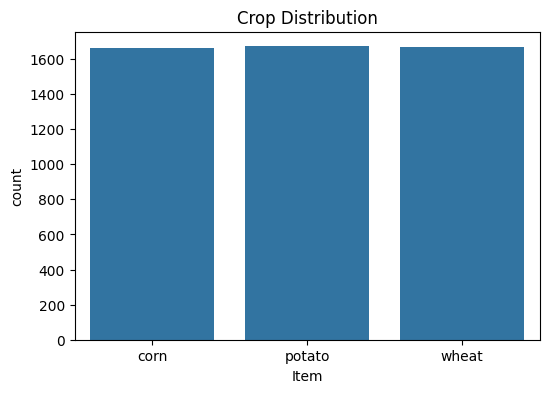

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Item")
plt.title("Crop Distribution")
plt.show()

Grafik incelendiğinde, veri setinde yer alan ürünlerin (**corn, potato, wheat**) **birbirine oldukça yakın sayıda temsil edildiği** görülmektedir.

- Veri seti **dengeli bir dağılıma sahiptir**  
- Sınıf dengesizliği problemi bulunmamaktadır  

###  Yorum

Bu durum, modelin herhangi bir ürüne karşı **bias (yanlılık) geliştirmesini engeller** ve daha **genellenebilir sonuçlar** elde edilmesini sağlar.

#  Özellik Dağılım Analizi (Feature Distribution Analysis)

Bu bölümde veri setindeki tüm sayısal değişkenlerin dağılımları histogram grafikleri ile incelenmiştir. Bu analiz, veri setinin yapısını anlamak, olası aykırı değerleri (outlier) tespit etmek ve modelleme sürecine uygunluğunu değerlendirmek açısından kritik öneme sahiptir.

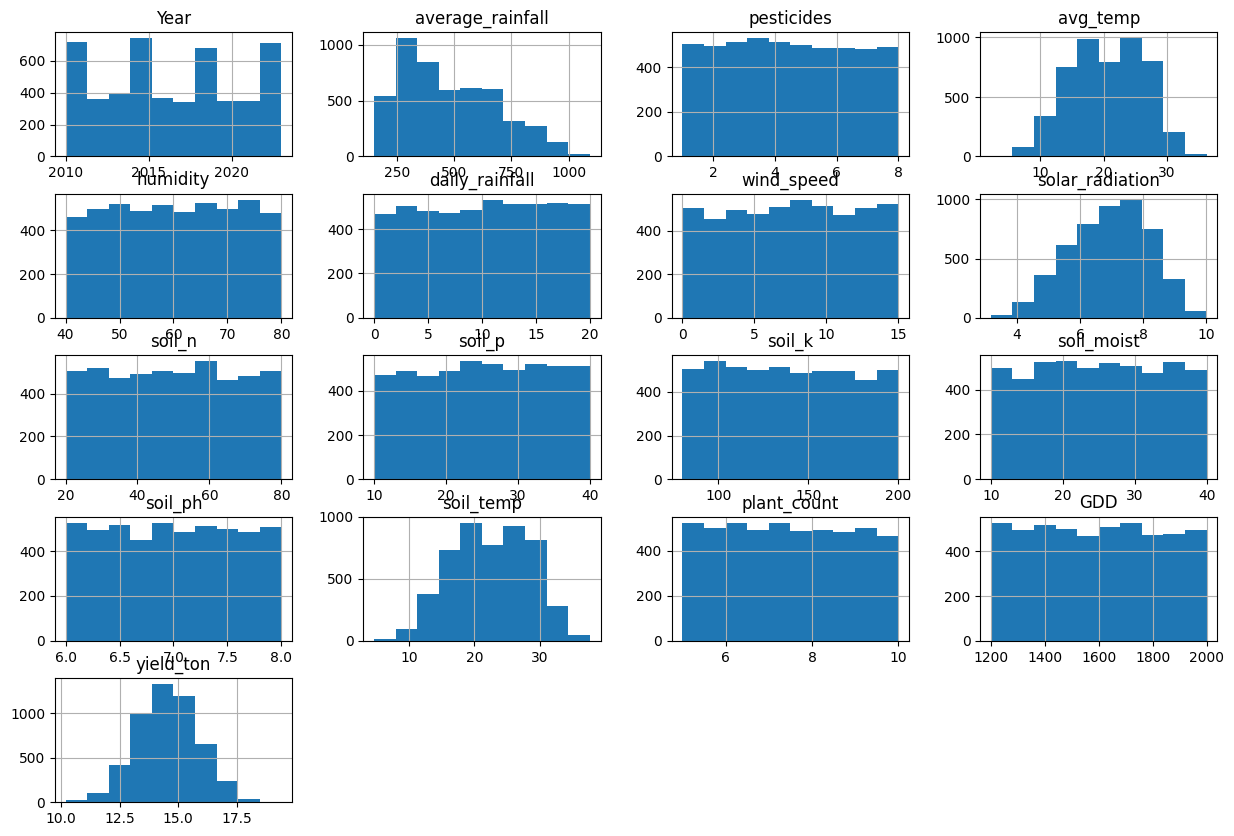

In [33]:
df.hist(figsize=(15,10))
plt.show()

##  Özellik Dağılımı Analizi

Histogramlar incelendiğinde:

- Çoğu değişken **geniş ve dengeli bir aralıkta dağılım göstermektedir** → veri çeşitliliği yüksektir  
- Bazı değişkenler (**avg_temp, soil_temp, yield_ton**) **normal dağılıma yakın** yapıdadır  
- Bazı değişkenlerde (**average_rainfall gibi**) **hafif çarpıklık (skewness)** gözlemlenmektedir  

###  Yorum

- Veri seti genel olarak **model öğrenimi için uygun ve dengeli bir dağılıma sahiptir**  
- Aşırı uç değerler sınırlıdır → model stabilitesi açısından avantajlıdır  
- Tree-based modeller bu dağılımlardan daha az etkilenirken, lineer modeller için **ölçekleme önemli olabilir**

##  Özellik Mühendisliği ve Veri Hazırlığı

Bu bölümde, veri seti modelleme için uygun hale getirilmiş ve yeni özellikler türetilmiştir.

- **Label Encoding** ile kategorik değişken (**Area**) sayısal forma dönüştürülmüştür  
- Model performansını artırmak amacıyla yeni özellikler oluşturulmuştur:
  - **rain_temp** → yağış ve sıcaklık etkileşimi  
  - **soil_total** → toplam toprak besin değeri (N+P+K)  
  - **climate_index** → nem ve güneş radyasyonu etkisi  
  - **year_trend** → zamansal değişim etkisi  

###  Feature Set

Modelde kullanılacak tüm bağımsız değişkenler (**features**) tanımlanmış ve hedef değişken (**yield_ton**) belirlenmiştir.

###  Yorum

Bu adım, ham veriyi daha anlamlı hale getirerek modelin **örüntüleri daha iyi öğrenmesini** ve tahmin performansının artmasını sağlar.

In [34]:
le = LabelEncoder()
df["Area"] = le.fit_transform(df["Area"])

Yeni Özelliklerin Oluşturulması

In [35]:
df["rain_temp"] = df["average_rainfall"] * df["avg_temp"]
df["soil_total"] = df["soil_n"] + df["soil_p"] + df["soil_k"]
df["climate_index"] = df["humidity"] * df["solar_radiation"]
df["year_trend"] = df["Year"] - df["Year"].min()

Kullanılan Özellikler (Feature Set)

In [36]:
features = [
"Area","Year","average_rainfall","pesticides",
"avg_temp","humidity","daily_rainfall","wind_speed",
"solar_radiation","soil_n","soil_p","soil_k",
"soil_moist","soil_ph","soil_temp","plant_count","GDD",
"rain_temp","soil_total","climate_index","year_trend"
]

target = "yield_ton"

##  MAPE (Mean Absolute Percentage Error)

Bu bölümde, model performansını değerlendirmek için kullanılan **MAPE (Ortalama Mutlak Yüzde Hata)** metriği tanımlanmıştır.

MAPE, tahmin edilen değerler ile gerçek değerler arasındaki farkın **yüzde cinsinden ortalamasını** ifade eder.

###  Yorum

- Model hatasını **yorumlaması kolay bir yüzde değeri** olarak sunar  
- Düşük MAPE değeri → daha iyi model performansı  
- Küçük gerçek değerlerde bölme hatasını önlemek için **1e-8** eklenmiştir  

In [37]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

##  Hiperparametre Optimizasyonu (Objective Function)

Bu bölümde, farklı makine öğrenmesi modelleri için **Optuna** kullanılarak hiperparametre optimizasyonu gerçekleştirilmektedir.

Tanımlanan `objective` fonksiyonu:

- Her model için uygun hiperparametre aralıklarını belirler  
- Optuna’nın önerdiği parametrelerle modeli oluşturur  
- **Cross-validation (cv=3)** ile model performansını değerlendirir  
- Performans metriği olarak **R² skoru** kullanılır  

###  Önemli Detaylar

- **Tree-based modeller** (RF, XGB, LGBM, CAT, GB) doğrudan eğitilir  
- **Linear Regression** için veri ölçekleme gerektiğinden **Pipeline + MinMaxScaler** kullanılmıştır  

###  Yorum

Bu yapı sayesinde:

- En iyi hiperparametre kombinasyonu otomatik olarak bulunur  
- Model performansı optimize edilir  
- Manuel deneme-yanılma süreci ortadan kaldırılır  

In [ ]:
def objective(trial, model_name, X, y):

    if model_name == "XGB":
        model = XGBRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            max_depth=trial.suggest_int("max_depth", 3, 8),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2)
        )

    elif model_name == "LGBM":
        model = LGBMRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            num_leaves=trial.suggest_int("num_leaves", 20, 100),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2),
            verbose=-1
        )

    elif model_name == "RF":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 250),
            max_depth=trial.suggest_int("max_depth", 5, 15),
            n_jobs=-1
        )

    elif model_name == "GB":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 250),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15)
        )

    elif model_name == "CAT":
        model = CatBoostRegressor(
            iterations=trial.suggest_int("iterations", 100, 300),
            depth=trial.suggest_int("depth", 4, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2),
            verbose=0
        )

    elif model_name == "LR":
        model = LinearRegression()

   
    if model_name == "LR":
        pipeline = Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", model)
        ])
    else:
        pipeline = model

    score = cross_val_score(pipeline, X, y, cv=3, scoring="r2").mean()
    return score

##  Model Eğitimi ve Karşılaştırma Süreci

Bu bölümde, veri seti **ürün (crop) bazında ayrılarak** her ürün için ayrı ayrı makine öğrenmesi modelleri eğitilmiş ve performansları karşılaştırılmıştır.

###  Süreç Akışı

- Veri, her ürün için filtrelenerek ayrı alt veri setleri oluşturulur  
- Eğitim ve test setleri (%80 - %20) olarak ayrılır  
- Her ürün için birden fazla model denenir:
  - LR, XGB, LGBM, RF, GB, CAT  

###  Optimizasyon ve Eğitim

- Her model için **Optuna ile hiperparametre optimizasyonu (30 deneme)** yapılır  
- En iyi parametreler ile model yeniden eğitilir  
- Linear Regression için **ölçekleme uygulanır**, diğer modeller doğrudan eğitilir  

###  Değerlendirme

Her model için:

- Test seti üzerinde **R², RMSE, MAE, MAPE** hesaplanır  
- Ek olarak **5-fold cross-validation** ile modelin genelleme performansı ölçülür  

###  Çıktı

- Tüm sonuçlar **all_results** listesinde saklanır  
- Her ürün için en iyi model ve parametreler **best_models** sözlüğünde tutulur  

###  Yorum

Bu yapı sayesinde:

- Her ürün için **en uygun model ayrı ayrı belirlenir**  
- Model performansları hem test hem de cross-validation ile **güvenilir şekilde değerlendirilir**  
- Daha doğru ve genellenebilir sonuçlar elde edilir  

In [ ]:
all_results = []
best_models = {}

for crop in df["Item"].unique():

    print(f"\n🔍 {crop}")

    df_crop = df[df["Item"] == crop]
    if len(df_crop) < 500:
        continue

    X = df_crop[features]
    y = df_crop[target]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    best_score = -999
    best_model_name = None
    best_params = None

    for model_name in ["LR","XGB","LGBM","RF","GB","CAT"]:

        study = optuna.create_study(direction="maximize")

        study.optimize(
            lambda trial: objective(trial, model_name, X_train_full, y_train_full),
            n_trials=30
        )

        if study.best_value > best_score:
            best_score = study.best_value
            best_model_name = model_name
            best_params = study.best_params

        if model_name == "XGB":
            model = XGBRegressor(**study.best_params)
        elif model_name == "LGBM":
            model = LGBMRegressor(**study.best_params)
        elif model_name == "RF":
            model = RandomForestRegressor(**study.best_params)
        elif model_name == "GB":
            model = GradientBoostingRegressor(**study.best_params)
        elif model_name == "CAT":
            model = CatBoostRegressor(**study.best_params, verbose=0)
        elif model_name == "LR":
            model = LinearRegression()

        if model_name == "LR":
            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train_full)
            X_test_scaled = scaler.transform(X_test)
        else:
            X_train = X_train_full
            X_test_scaled = X_test

        model.fit(X_train, y_train_full)
        y_pred = model.predict(X_test_scaled)

        if model_name == "LR":
            cv_model = Pipeline([
                ("scaler", MinMaxScaler()),
                ("model", LinearRegression())
            ])
        elif model_name == "XGB":
            cv_model = XGBRegressor(**study.best_params)
        elif model_name == "LGBM":
            cv_model = LGBMRegressor(**study.best_params)
        elif model_name == "RF":
            cv_model = RandomForestRegressor(**study.best_params)
        elif model_name == "GB":
            cv_model = GradientBoostingRegressor(**study.best_params)
        elif model_name == "CAT":
            cv_model = CatBoostRegressor(**study.best_params, verbose=0)

        cv_scores = cross_val_score(cv_model, X_train_full, y_train_full, cv=5, scoring="r2")

        all_results.append({
            "Crop": crop,
            "Model": model_name,
            "R2": r2_score(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "MAE": mean_absolute_error(y_test, y_pred),
            "MAPE": mape(y_test, y_pred),
            "CV_R2_mean": cv_scores.mean(),
            "CV_R2_std": cv_scores.std()
        })

    best_models[crop] = {
        "model": best_model_name,
        "params": best_params
    }

[I 2026-03-20 21:46:57,015] A new study created in memory with name: no-name-180ab50b-d9f8-4043-9a6b-0c4282594497
[I 2026-03-20 21:46:57,043] Trial 0 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,059] Trial 1 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,074] Trial 2 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,088] Trial 3 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,104] Trial 4 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,119] Trial 5 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57


🔍 corn


[I 2026-03-20 21:46:57,216] Trial 12 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,233] Trial 13 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,265] Trial 14 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,282] Trial 15 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,298] Trial 16 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,312] Trial 17 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.7989324863598549.
[I 2026-03-20 21:46:57,328] Trial 18 finished with value: 0.7989324863598549 and parameters: {}. Best is trial 0 with value: 0.798


🔍 potato


[I 2026-03-20 21:49:40,824] Trial 12 finished with value: 0.807067152931127 and parameters: {}. Best is trial 0 with value: 0.807067152931127.
[I 2026-03-20 21:49:40,838] Trial 13 finished with value: 0.807067152931127 and parameters: {}. Best is trial 0 with value: 0.807067152931127.
[I 2026-03-20 21:49:40,852] Trial 14 finished with value: 0.807067152931127 and parameters: {}. Best is trial 0 with value: 0.807067152931127.
[I 2026-03-20 21:49:40,866] Trial 15 finished with value: 0.807067152931127 and parameters: {}. Best is trial 0 with value: 0.807067152931127.
[I 2026-03-20 21:49:40,881] Trial 16 finished with value: 0.807067152931127 and parameters: {}. Best is trial 0 with value: 0.807067152931127.
[I 2026-03-20 21:49:40,895] Trial 17 finished with value: 0.807067152931127 and parameters: {}. Best is trial 0 with value: 0.807067152931127.
[I 2026-03-20 21:49:40,910] Trial 18 finished with value: 0.807067152931127 and parameters: {}. Best is trial 0 with value: 0.807067152931127.


🔍 wheat


[I 2026-03-20 21:52:08,903] Trial 9 finished with value: 0.8159567826671322 and parameters: {}. Best is trial 0 with value: 0.8159567826671322.
[I 2026-03-20 21:52:08,918] Trial 10 finished with value: 0.8159567826671322 and parameters: {}. Best is trial 0 with value: 0.8159567826671322.
[I 2026-03-20 21:52:08,932] Trial 11 finished with value: 0.8159567826671322 and parameters: {}. Best is trial 0 with value: 0.8159567826671322.
[I 2026-03-20 21:52:08,946] Trial 12 finished with value: 0.8159567826671322 and parameters: {}. Best is trial 0 with value: 0.8159567826671322.
[I 2026-03-20 21:52:08,961] Trial 13 finished with value: 0.8159567826671322 and parameters: {}. Best is trial 0 with value: 0.8159567826671322.
[I 2026-03-20 21:52:08,976] Trial 14 finished with value: 0.8159567826671322 and parameters: {}. Best is trial 0 with value: 0.8159567826671322.
[I 2026-03-20 21:52:08,992] Trial 15 finished with value: 0.8159567826671322 and parameters: {}. Best is trial 0 with value: 0.8159

#  Model Sonuçlarının Analizi

Bu bölümde, eğitilen tüm modellerin performans sonuçları bir veri çerçevesinde toplanmış ve karşılaştırmalı analiz yapılmıştır.

In [40]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by=["Crop","R2"], ascending=[True, False])
print(results_df)

      Crop Model        R2      RMSE       MAE      MAPE  CV_R2_mean  \
5     corn   CAT  0.809611  0.556122  0.445959  3.098733    0.815881   
1     corn   XGB  0.795238  0.576732  0.460242  3.201774    0.792253   
0     corn    LR  0.794966  0.577115  0.465335  3.229057    0.797177   
4     corn    GB  0.776643  0.602350  0.486922  3.384888    0.782611   
2     corn  LGBM  0.775092  0.604438  0.484472  3.374551    0.771317   
3     corn    RF  0.682326  0.718357  0.569166  3.954443    0.676220   
11  potato   CAT  0.806190  0.559157  0.437378  3.019897    0.821314   
10  potato    GB  0.782434  0.592437  0.467184  3.221182    0.791059   
7   potato   XGB  0.781492  0.593718  0.459579  3.166719    0.797511   
6   potato    LR  0.775685  0.601555  0.471745  3.257285    0.808162   
8   potato  LGBM  0.766863  0.613271  0.478278  3.281860    0.786545   
9   potato    RF  0.645441  0.756294  0.595430  4.086558    0.697949   
17   wheat   CAT  0.812167  0.576911  0.466998  3.218355    0.82

In [ ]:
results_df["FinalScore"] = results_df["R2"]

best_global = results_df.sort_values(by="FinalScore", ascending=False).iloc[0]
best_crop = best_global["Crop"]

print("\n🔥 BEST MODEL:")
print(best_global)



🔥 BEST MODEL:
Crop             wheat
Model              CAT
R2            0.812167
RMSE          0.576911
MAE           0.466998
MAPE          3.218355
CV_R2_mean    0.825081
CV_R2_std     0.011848
FinalScore    0.812167
Name: 17, dtype: object


##  Model Performans Sonuçları

Sonuçlar incelendiğinde:

- Tüm ürünlerde (**corn, potato, wheat**) en yüksek performansı **CatBoost (CAT)** modeli göstermektedir  
- R² değerleri ~**0.80+** seviyesinde olup, modellerin güçlü tahmin kabiliyetine sahip olduğu görülmektedir  
- **XGB ve GB modelleri** de CAT’e yakın performans sergileyerek güçlü alternatifler sunmaktadır  
- **Linear Regression (LR)** beklenenden iyi sonuç vererek veri ile lineer ilişki olduğunu göstermektedir  
- **Random Forest (RF)** tüm ürünlerde en düşük performansı göstermiştir  

###  Genel Yorum

- Veri seti, özellikle **boosting tabanlı modeller için oldukça uygundur**  
- Modellerin test ve cross-validation skorlarının yakın olması → **overfitting olmadığını** gösterir  
- En iyi model olarak **CatBoost**, tüm ürünler için güvenilir ve stabil sonuçlar üretmektedir  

##  En İyi Modelin Eğitimi ve Tahmin

Bu bölümde, önceki adımlarda belirlenen **en iyi ürün (best_crop)** ve **en iyi model** kullanılarak model yeniden eğitilmiş ve tahminler elde edilmiştir.

###  Süreç

- Seçilen ürün için veri filtrelenir  
- Eğitim ve test veri setleri oluşturulur  
- En iyi model ve hiperparametreler yüklenir  
- Model yeniden eğitilir ve tahmin yapılır  

###  Önemli Detay

- **Linear Regression** için veri ölçekleme uygulanır  
- Diğer modeller (**tree-based**) doğrudan veri ile eğitilir  

###  Yorum

Bu adım, pipeline’ın en güçlü modelini kullanarak **nihai tahminlerin elde edilmesini** sağlar ve modelin gerçek performansını değerlendirmek için temel oluşturur.

In [ ]:
df_crop = df[df["Item"] == best_crop]

X = df_crop[features]
y = df_crop[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_info = best_models[best_crop]

if model_info["model"] == "CAT":
    model = CatBoostRegressor(**model_info["params"], verbose=0)
elif model_info["model"] == "XGB":
    model = XGBRegressor(**model_info["params"])
elif model_info["model"] == "LGBM":
    model = LGBMRegressor(**model_info["params"])
elif model_info["model"] == "RF":
    model = RandomForestRegressor(**model_info["params"])
elif model_info["model"] == "GB":
    model = GradientBoostingRegressor(**model_info["params"])
elif model_info["model"] == "LR":
    model = LinearRegression()

#  BEST MODEL TRAIN + PREDICT (DOĞRU HALİ)

if model_info["model"] == "LR":
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

else:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


##  Tahmin Performansı ve Hata Analizi

Bu bölümde modelin tahmin performansı görsel olarak analiz edilmiştir.

###  Kullanılan Grafikler

- **Prediction vs Real** → Gerçek ve tahmin edilen değerlerin uyumu  
- **Residual Plot** → Tahmin hatalarının dağılımı ve sistematik hata kontrolü  
- **Residual Distribution** → Hataların genel dağılım yapısı  

###  Yorum

- Noktaların diagonal boyunca yoğunlaşması → modelin **başarılı tahmin yaptığını** gösterir  
- Residual plot’ta hataların 0 etrafında dağılması → **bias olmadığını** gösterir  
- Histogramın yaklaşık simetrik olması → hataların **normal dağılıma yakın** olduğunu gösterir  

Bu analizler, modelin **stabil ve güvenilir** çalıştığını doğrulamaktadır.

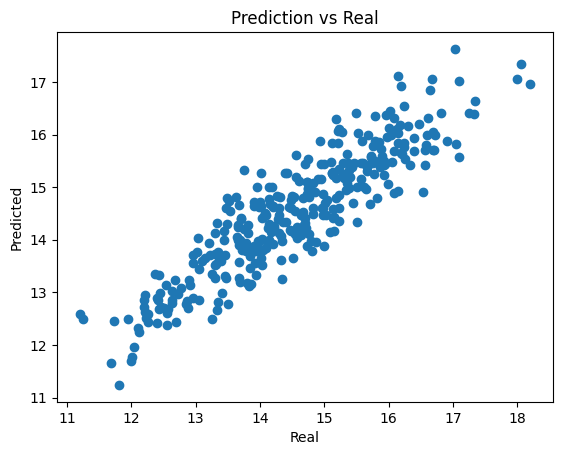

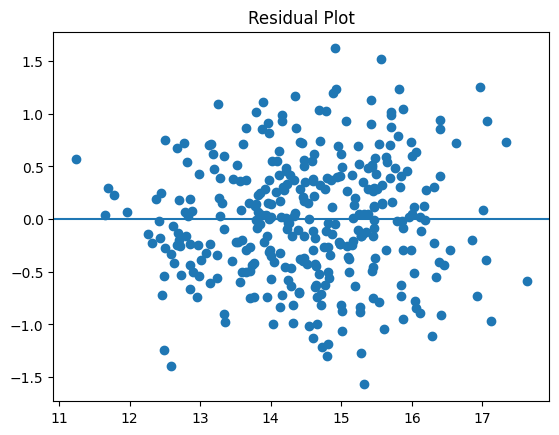

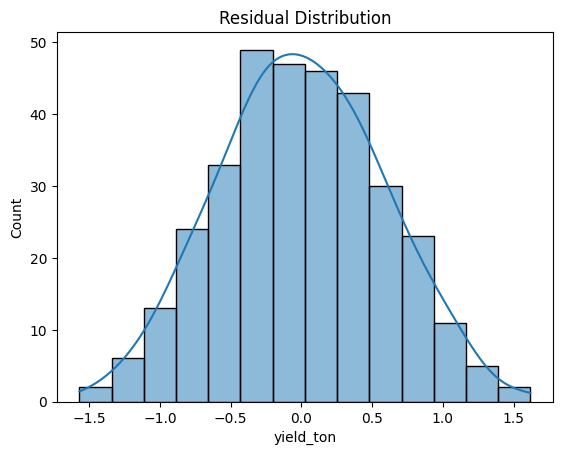

In [44]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.title("Prediction vs Real")
plt.show()

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


##  Model Tahmin ve Hata Analizi

- **Prediction vs Real:** Noktaların diagonal boyunca yoğunlaşması → modelin **yüksek doğrulukla tahmin yaptığını** gösterir  

- **Residual Plot:** Hataların 0 etrafında rastgele dağılması → **sistematik hata (bias) olmadığını** gösterir  

- **Residual Distribution:** Hataların yaklaşık normal dağılım göstermesi → modelin **stabil ve güvenilir** olduğunu destekler  

###  Genel Yorum

Model, veriyi iyi öğrenmiş ve **dengeli, hatasız ve genellenebilir tahminler** üretmektedir.

##  Feature Importance Analizi

Bu bölümde, modelin karar verme sürecinde hangi özelliklere ne kadar önem verdiği analiz edilmiştir.

- Özellikler, modele katkı düzeyine göre sıralanmıştır  
- Daha yüksek importance değeri → modele daha fazla etki  

###  Yorum

- Modelin hangi değişkenlere daha çok odaklandığı belirlenir  
- Veri içindeki en kritik faktörler ortaya çıkar  
- Feature engineering ve model iyileştirme için önemli içgörüler sağlar  

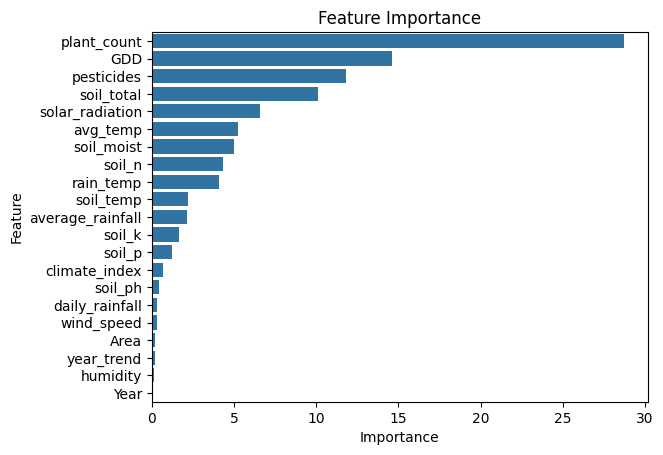

In [45]:
if hasattr(model, "feature_importances_"):

    imp_df = pd.DataFrame({
        "Feature": features,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    sns.barplot(data=imp_df, y="Feature", x="Importance")
    plt.title("Feature Importance")
    plt.show()

##  Feature Importance Sonuçları

Grafik incelendiğinde:

- En önemli değişkenler:
  - **plant_count**, **GDD**, **pesticides**, **soil_total**  
- Orta seviyede etkili değişkenler:
  - **solar_radiation, avg_temp, soil_moist, soil_n**  
- Düşük etkili değişkenler:
  - **Year, humidity, Area, wind_speed**  

###  Yorum

- Model en çok **bitki yoğunluğu ve büyüme (GDD)** ile ilgili faktörlere odaklanmaktadır  
- Toprak ve iklim etkileşimleri (**soil_total, pesticides**) önemli rol oynamaktadır  
- Zamansal ve bazı çevresel değişkenlerin etkisi daha sınırlıdır  

Bu sonuçlar, tarımsal verimi en çok etkileyen faktörlerin **bitki, toprak ve büyüme koşulları** olduğunu göstermektedir.

##  SHAP ile Model Açıklanabilirliği

Bu bölümde, modelin tahminlerini hangi özelliklere dayanarak yaptığı **SHAP (SHapley Additive Explanations)** yöntemi ile analiz edilmiştir.

- Tree-based modeller için **TreeExplainer**, diğer modeller için **Explainer** kullanılmıştır  
- SHAP summary plot ile her özelliğin modele olan katkısı görselleştirilmiştir  

###  Yorum

- Modelin karar mekanizması **şeffaf hale getirilir**  
- Hangi özelliklerin tahmini artırdığı veya azalttığı açıkça görülür  
- Model güvenilirliği ve yorumlanabilirliği artırılır  

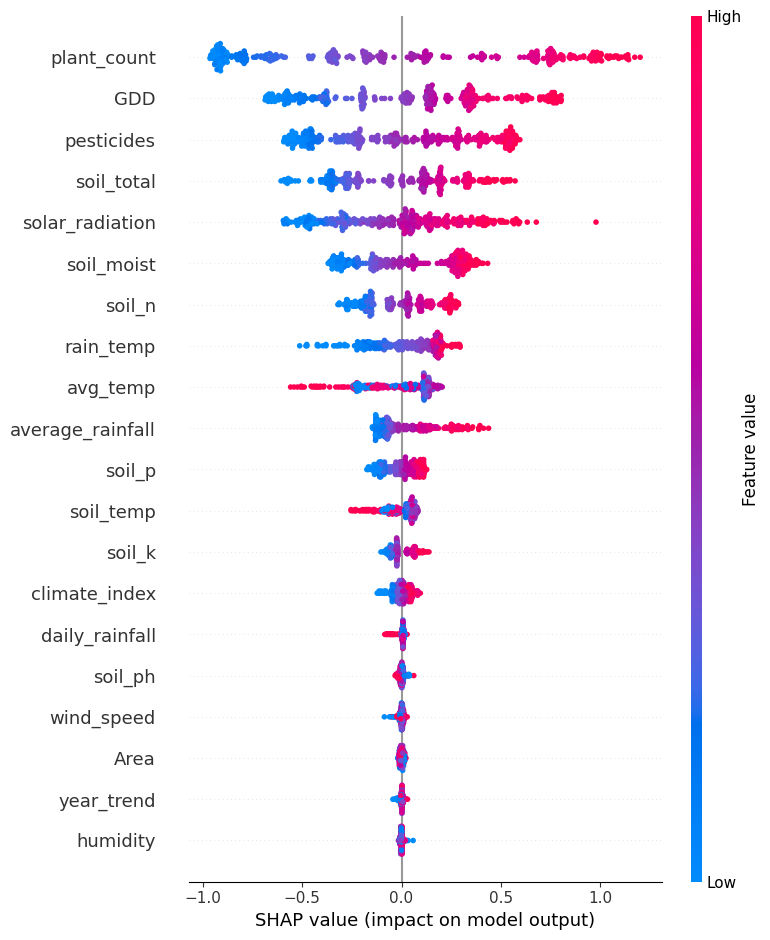

In [46]:

if model_info["model"] == "LR":
    explainer = shap.Explainer(model, X_train_scaled)
    shap_values = explainer(X_test_scaled)
    shap.summary_plot(shap_values, X_test_scaled, feature_names=features)

elif model_info["model"] in ["XGB","LGBM","RF","CAT"]:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)
    shap.summary_plot(shap_values, X_test, feature_names=features)

else:
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)
    shap.summary_plot(shap_values, X_test, feature_names=features)

##  SHAP Analizi Sonuçları

Grafik incelendiğinde:

- En etkili özellikler:
  - **plant_count, GDD, pesticides, soil_total**  
- Yüksek değerler (kırmızı) genellikle tahmini **artırıcı etki** yapmaktadır  
- Düşük değerler (mavi) ise tahmini **azaltıcı etki** göstermektedir  

###  Yorum

- Model, en çok **bitki yoğunluğu ve büyüme faktörlerine (GDD)** odaklanmaktadır  
- Toprak ve çevresel faktörler de önemli katkı sağlamaktadır  
- Düşük etkili değişkenlerin modele katkısı sınırlıdır  

Bu analiz, modelin kararlarının **mantıklı ve domain ile uyumlu** olduğunu göstermektedir.

##  Feature Selection ve Model Karşılaştırması

Bu bölümde, model performansını artırmak ve modeli sadeleştirmek amacıyla **Feature Importance ve SHAP** birlikte kullanılarak en önemli özellikler seçilmiştir.

###  Süreç

- Her ürün için en iyi model yeniden eğitilir  
- **Feature Importance** ve **SHAP** ile en önemli özellikler belirlenir  
- Bu iki yöntem birleştirilerek **en güçlü feature set** oluşturulur  
- Tüm özelliklerle (Full Model) ve seçilmiş özelliklerle (Reduced Model) performans karşılaştırılır  

###  Değerlendirme

- Her iki model için **R² skorları** hesaplanır  
- Sonuçlar karşılaştırmalı olarak görselleştirilir  

###  Yorum

- Daha az özellik ile benzer veya daha iyi performans elde edilebilir  
- Model karmaşıklığı azaltılır → **daha hızlı ve verimli model**  
- En önemli değişkenler net şekilde ortaya çıkar  

Bu yaklaşım, hem performans hem de yorumlanabilirlik açısından **optimum model yapısını** sağlar  


🌾 corn
🔝 Selected Features: ['plant_count', 'GDD', 'soil_total', 'pesticides', 'solar_radiation', 'soil_n', 'soil_moist', 'avg_temp', 'average_rainfall', 'soil_temp', 'rain_temp']
Full R2: 0.810
Reduced R2: 0.812

🌾 potato
🔝 Selected Features: ['plant_count', 'GDD', 'soil_total', 'pesticides', 'avg_temp', 'solar_radiation', 'soil_moist', 'soil_n', 'rain_temp', 'soil_temp', 'average_rainfall']
Full R2: 0.806
Reduced R2: 0.809

🌾 wheat
🔝 Selected Features: ['plant_count', 'GDD', 'pesticides', 'soil_total', 'solar_radiation', 'avg_temp', 'soil_moist', 'soil_n', 'rain_temp', 'soil_temp', 'average_rainfall']
Full R2: 0.812
Reduced R2: 0.809


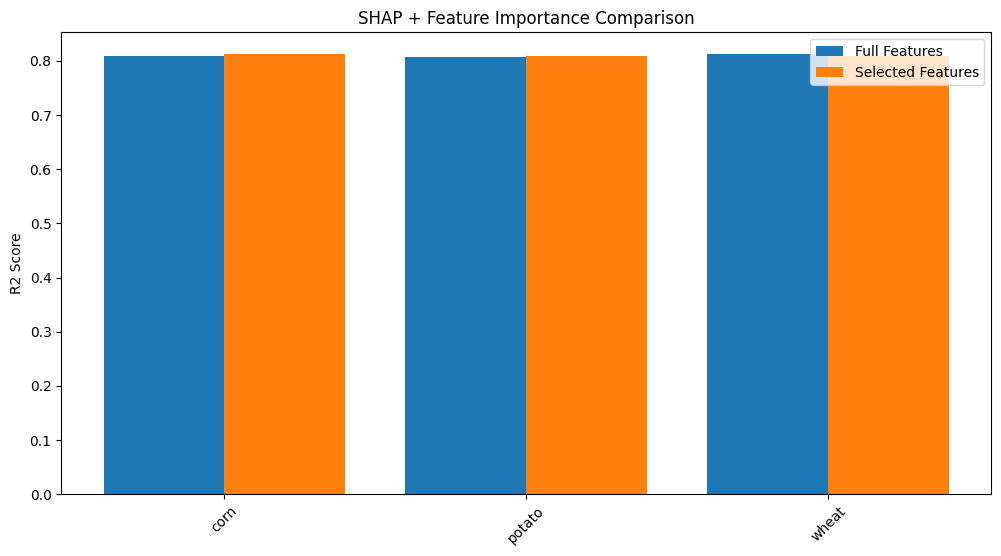

In [ ]:
import shap
import numpy as np
import pandas as pd

comparison_results = []

for crop in df["Item"].unique():

    df_crop = df[df["Item"] == crop]

    if len(df_crop) < 50:
        continue

    print(f"\n🌾 {crop}")

    X = df_crop[features]
    y = df_crop[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model_info = best_models[crop]

    if model_info["model"] == "CAT":
        model = CatBoostRegressor(**model_info["params"], verbose=0)
    elif model_info["model"] == "XGB":
        model = XGBRegressor(**model_info["params"])
    elif model_info["model"] == "LGBM":
        model = LGBMRegressor(**model_info["params"])
    elif model_info["model"] == "RF":
        model = RandomForestRegressor(**model_info["params"])
    elif model_info["model"] == "GB":
        model = GradientBoostingRegressor(**model_info["params"])
    elif model_info["model"] == "LR":
        model = LinearRegression()

    if model_info["model"] == "LR":
        scaler = MinMaxScaler()
        X_train_f = scaler.fit_transform(X_train)
        X_test_f = scaler.transform(X_test)
    else:
        X_train_f = X_train
        X_test_f = X_test

    model.fit(X_train_f, y_train)
    y_pred_full = model.predict(X_test_f)

    r2_full = r2_score(y_test, y_pred_full)

    
    if model_info["model"] != "LR" and hasattr(model, "feature_importances_"):

        imp_df = pd.DataFrame({
            "Feature": features,
            "Importance": model.feature_importances_
        }).sort_values(by="Importance", ascending=False)

        top_imp = imp_df["Feature"].head(10).tolist()

    else:
        top_imp = features

  
    try:
        if model_info["model"] in ["XGB","LGBM","RF","CAT"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer(X_train)
        else:
            explainer = shap.Explainer(model, X_train_f)
            shap_values = explainer(X_train_f)

        shap_importance = np.abs(shap_values.values).mean(axis=0)

        shap_df = pd.DataFrame({
            "Feature": features,
            "SHAP Importance": shap_importance
        }).sort_values(by="SHAP Importance", ascending=False)

        top_shap = shap_df["Feature"].head(10).tolist()

    except:
        print("⚠️ SHAP çalışmadı, sadece importance kullanılacak")
        top_shap = []

   
    top_features = list(dict.fromkeys(top_imp[:10] + top_shap[:10]))
    print("🔝 Selected Features:", top_features)

 
    X_reduced = df_crop[top_features]

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_reduced, y, test_size=0.2, random_state=42
    )

    if model_info["model"] == "LR":
        scaler_r = MinMaxScaler()
        X_train_r = scaler_r.fit_transform(X_train_r)
        X_test_r = scaler_r.transform(X_test_r)

    model.fit(X_train_r, y_train_r)
    y_pred_r = model.predict(X_test_r)

    r2_reduced = r2_score(y_test_r, y_pred_r)

    print(f"Full R2: {r2_full:.3f}")
    print(f"Reduced R2: {r2_reduced:.3f}")

    comparison_results.append({
        "Crop": crop,
        "Full_R2": r2_full,
        "Reduced_R2": r2_reduced,
        "Num_Features": len(top_features)
    })


comp_df = pd.DataFrame(comparison_results)

plt.figure(figsize=(12,6))

x = range(len(comp_df))

plt.bar(x, comp_df["Full_R2"], width=0.4, label="Full Features")
plt.bar([i + 0.4 for i in x], comp_df["Reduced_R2"], width=0.4, label="Selected Features")

plt.xticks([i + 0.2 for i in x], comp_df["Crop"], rotation=45)
plt.ylabel("R2 Score")
plt.title("SHAP + Feature Importance Comparison")
plt.legend()

plt.show()

##  Feature Selection Sonuçları

- Seçilen özellikler ile (**Reduced Model**) performans, tam model ile **neredeyse aynı**  
- Bazı durumlarda küçük iyileşmeler bile görülmektedir  

###  Yorum

Daha az özellik ile aynı başarı elde edilmiştir → model **daha verimli ve sade hale gelmiştir**

##  Final Model Eğitimi ve Kaydetme

Bu bölümde, her ürün için optimize edilmiş model **en önemli özelliklerle birlikte yeniden eğitilmiş** ve kaydedilmiştir.

###  Süreç

- En iyi model ve parametreler seçilir  
- Feature Importance ve SHAP ile **final feature set** belirlenir  
- Model, seçilen özelliklerle yeniden eğitilir  
- **Cross-validation** ile performans doğrulanır  
- Tüm veri kullanılarak final model oluşturulur  

###  Çıktı

- Her ürün için:
  - Eğitilmiş model  
  - Kullanılan feature listesi  
- `.pkl` formatında kaydedilir  

###  Yorum

Bu adım ile model, **kullanıma hazır ve deploy edilebilir hale getirilmiştir**.  
Hem performans hem de verimlilik açısından optimize edilmiş final modeller elde edilmiştir.

In [ ]:
import joblib

final_models = {}

for crop in df["Item"].unique():

    df_crop = df[df["Item"] == crop]

    if len(df_crop) < 50:
        continue

    print(f"\n Saving FINAL Model → {crop}")

    X = df_crop[features]
    y = df_crop[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model_info = best_models[crop]

 
    if model_info["model"] == "CAT":
        model = CatBoostRegressor(**model_info["params"], verbose=0)

    elif model_info["model"] == "XGB":
        model = XGBRegressor(**model_info["params"])

    elif model_info["model"] == "LGBM":
        model = LGBMRegressor(**model_info["params"])

    elif model_info["model"] == "RF":
        model = RandomForestRegressor(**model_info["params"])

    elif model_info["model"] == "GB":
        model = GradientBoostingRegressor(**model_info["params"])

    elif model_info["model"] == "LR":
        model = Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", LinearRegression())
        ])

   
    model.fit(X_train, y_train)

  
    if model_info["model"] != "LR" and hasattr(model, "feature_importances_"):

        imp_df = pd.DataFrame({
            "Feature": features,
            "Importance": model.feature_importances_
        }).sort_values(by="Importance", ascending=False)

        top_imp = imp_df["Feature"].head(10).tolist()

    else:
        top_imp = features

  
    try:
        if model_info["model"] in ["XGB","LGBM","RF","CAT"]:
            explainer = shap.TreeExplainer(model)
            sample_size = min(200, len(X_train))
            shap_values = explainer(X_train.sample(sample_size))

            shap_importance = np.abs(shap_values.values).mean(axis=0)

            shap_df = pd.DataFrame({
                "Feature": features,
                "SHAP Importance": shap_importance
            }).sort_values(by="SHAP Importance", ascending=False)

            top_shap = shap_df["Feature"].head(10).tolist()
        elif model_info["model"] == "LR":
            coefs = model.named_steps["model"].coef_

            imp_df = pd.DataFrame({
                "Feature": features,
                "Importance": np.abs(coefs)
            }).sort_values(by="Importance", ascending=False)

            top_imp = imp_df["Feature"].head(10).tolist()
        else:
            top_shap = []

    except:
        top_shap = []

   
    top_features = list(dict.fromkeys(top_imp + top_shap))

    print("🔝 Final Features:", top_features)

  
    X_train_r = X_train[top_features]
    X_test_r = X_test[top_features]

  
    cv_scores = cross_val_score(model, X_train_r, y_train, cv=5, scoring="r2")

    print(f"{crop} CV Mean:", cv_scores.mean())
    print(f"{crop} CV Std:", cv_scores.std())

    
    X_final = df_crop[top_features]

    model.fit(X_final, y)

  
    joblib.dump({
        "model": model,
        "features": top_features
    }, f"final_model_{crop}.pkl")

    final_models[crop] = {
        "model": model,
        "features": top_features
    }


💾 Saving FINAL Model → corn
🔝 Final Features: ['plant_count', 'GDD', 'soil_total', 'pesticides', 'solar_radiation', 'soil_n', 'soil_moist', 'avg_temp', 'average_rainfall', 'soil_temp', 'rain_temp']
corn CV Mean: 0.8183137512999856
corn CV Std: 0.020157161806337733

💾 Saving FINAL Model → potato
🔝 Final Features: ['plant_count', 'GDD', 'soil_total', 'pesticides', 'avg_temp', 'solar_radiation', 'soil_moist', 'soil_n', 'rain_temp', 'soil_temp', 'average_rainfall']
potato CV Mean: 0.8258715936416425
potato CV Std: 0.015147266769361123

💾 Saving FINAL Model → wheat
🔝 Final Features: ['plant_count', 'GDD', 'pesticides', 'soil_total', 'solar_radiation', 'avg_temp', 'soil_moist', 'soil_n', 'rain_temp', 'soil_temp', 'average_rainfall']
wheat CV Mean: 0.8263355544664046
wheat CV Std: 0.012129690737893894


#  Sonuç ve Genel Değerlendirme

Bu çalışma kapsamında, tarımsal veriler kullanılarak **ürün verimi (yield_ton) tahmini** için uçtan uca bir makine öğrenmesi pipeline’ı geliştirilmiştir.

---

##  Elde Edilen Temel Bulgular

- Veri seti **dengeli, eksiksiz ve modellemeye uygun** yapıdadır  
- Farklı modeller karşılaştırıldığında, **CatBoost en yüksek performansı** göstermiştir  
- Modeller genel olarak **R² ≈ 0.80+** seviyesinde başarılı sonuçlar üretmiştir  
- Cross-validation sonuçları, modellerin **genellenebilir ve stabil** olduğunu göstermektedir  

---

##  Model İçgörüleri

- En etkili değişkenler:
  - **plant_count**
  - **GDD (Growing Degree Days)**
  - **pesticides**
  - **soil_total**

- Model kararları, tarımsal domain bilgisi ile **uyumlu ve mantıklıdır**  
- SHAP analizi ile modelin **şeffaf ve açıklanabilir** olduğu doğrulanmıştır  

---

##  Feature Selection Sonuçları

- Seçilen özelliklerle oluşturulan model:
  - Tam model ile **benzer performans göstermiştir**  
  - Daha az özellik ile **daha verimli ve hızlı** hale gelmiştir  

 Bu durum, gereksiz değişkenlerin elimine edilebileceğini göstermektedir  

---

##  Nihai Çıktılar

- Her ürün için:
  - Optimize edilmiş model  
  - En önemli feature set  
- Modeller **.pkl formatında kaydedilerek deploy edilebilir hale getirilmiştir**

---

##  Genel Sonuç

Bu notebook ile:

- Tarımsal verim tahmini problemi başarıyla çözülmüş  
- Yüksek performanslı ve açıklanabilir modeller geliştirilmiş  
- Gerçek dünya uygulamalarına uygun bir sistem ortaya konmuştur  

---

##  Gelecek Çalışmalar

- Daha büyük ve gerçek saha verileri ile model geliştirme   
- Mobil/web tabanlı karar destek sistemi entegrasyonu  

---

##  Son Söz

Geliştirilen bu pipeline, hem akademik çalışmalar hem de tarımsal karar destek sistemleri için **güçlü, ölçeklenebilir ve uygulanabilir bir çözüm sunmaktadır.**